# Food Safety Risk Patterns in Chicago

## 1. Introduction and Research Question

This project analyzes Chicago food inspection outcomes for consumers and public health stakeholders. The goal is to identify inspection, facility, time, and ZIP/ZCTA context patterns associated with higher observed failure risk, without ranking individual restaurants.

The analysis uses two datasets: Chicago Food Inspections records and Census ACS ZIP/ZCTA context. The datasets are integrated in SQLite using ZIP/ZCTA code, then analyzed with SQL and Python.

**Research question:** Which facility types, risk levels, inspection types, time patterns, and ZIP/ZCTA area contexts are associated with higher Chicago food inspection failure risk?

## 2. Data Sources


### 2.1 Dataset 1: Chicago Food Inspections

Inspection-level records from the Chicago Data Portal, including facility details, dates, inspection types, risk categories, results, ZIP codes, and violations.

### 2.2 Dataset 2: Census ACS ZIP/ZCTA Context

ZIP/ZCTA-level ACS context, including population, income, poverty, education, and age composition. These variables describe areas, not individual establishments.

## 3. Dataset 1 Collection: Chicago Food Inspections API

Dataset 1 is collected from the Chicago Food Inspections API. This section verifies the endpoint, defines the fixed date scope, and downloads the records with pagination.

In [1]:
import requests
import json
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt
import time

### 3.1 API Endpoint and Request Test

Before downloading the full dataset, I send a small request to confirm that the Chicago Food Inspections endpoint is accessible and returns JSON records.

In [2]:
# Chicago Food Inspections API endpoint
url = "https://data.cityofchicago.org/resource/4ijn-s7e5.json"

# Test the API with a small number of records
params = {
    "$limit": 5
}

response = requests.get(url, params=params)

print(response.status_code)

200


The status code is 200, which means the API request was successful. I then inspect a few returned records to understand the structure of the JSON response.

In [3]:
test_df = pd.DataFrame(response.json())
test_df

,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,city,state,zip,...,results,violations,latitude,longitude,location,:@computed_region_awaf_s7ux,:@computed_region_6mkv_f3dw,:@computed_region_vrxf_vc4k,:@computed_region_bdys_3d7i,:@computed_region_43wa_7qmu
0,2637326,NICKY'S,NICKY'S,7813,Restaurant,Risk 1 (High),5801 S KEDZIE AVE,CHICAGO,IL,60629,...,Pass,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,41.787976364169765,-87.70325124213517,"{'latitude': '41.787976364169765', 'longitude'...",49,21867,61,764,8
1,2637321,SUBWAY 24453,SUBWAY 24453,2856691,Restaurant,Risk 1 (High),111 N WABASH AVE,CHICAGO,IL,60602,...,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.88352649174743,-87.62608219678731,"{'latitude': '41.88352649174743', 'longitude':...",22,14310,38,580,36
2,2637312,MI FUENTE,MI FUENTE,3082412,NaN,NaN,2946-2950 W 59TH ST,CHICAGO,IL,60629,...,Not Ready,NaN,41.78644723705288,-87.69790782922276,"{'latitude': '41.78644723705288', 'longitude':...",49,21867,61,764,2
3,2637318,BRENDA'S KIDS CLUB DAYCARE CENTER,BRENDA'S KIDS CLUB DAYCARE CENTER,2215916,Daycare Above and Under 2 Years,Risk 1 (High),3552 E 118TH ST,CHICAGO,IL,60617,...,Pass,NaN,41.681053268167084,-87.53683432709336,"{'latitude': '41.681053268167084', 'longitude'...",47,21202,52,787,47
4,2637306,L' ANGOLO ITALIANO,L' ANGOLO ITALIANO,3082311,Restaurant,Risk 1 (High),1538 W JARVIS AVE,CHICAGO,IL,60626,...,Pass,NaN,42.016111515067536,-87.66973658889663,"{'latitude': '42.016111515067536', 'longitude'...",3,21853,10,357,5


### 3.2 Record Count and Date Scope

The analysis uses inspection records from 2019-01-01 through 2026-04-30, matching the date coverage of the midterm dataset. A count query checks the expected record volume before downloading the data.

In [4]:
# Count the number of inspection records from 2019 onward
params = {
    "$select": "count(*)",
    "$where": "inspection_date >= '2019-01-01T00:00:00' AND inspection_date <= '2026-04-30T23:59:59'"
}

response = requests.get(url, params=params)

print(response.status_code)
pprint(response.json())

200
[{'count': '129274'}]


The count query currently returns 129,274 inspection records for 2019-01-01 through 2026-04-30.

### 3.3 Paginated Data Download

The API download uses `$limit` and `$offset` to retrieve all records in the fixed date range.

In [5]:
limit = 50000
offset = 0
all_records = []

while True:
    params = {
        "$limit": limit,
        "$offset": offset,
        "$where": "inspection_date >= '2019-01-01T00:00:00' AND inspection_date <= '2026-04-30T23:59:59'"
    }

    response = requests.get(url, params=params)
    print(response.status_code)

    records = response.json()
    if len(records) == 0:
        break

    all_records.extend(records)
    print("Downloaded", len(all_records), "records so far")

    offset += limit
    time.sleep(0.2)

food_df = pd.DataFrame(all_records)

200
Downloaded 50000 records so far
200
Downloaded 100000 records so far
200
Downloaded 129274 records so far
200


## 4. Dataset 1 Preparation: Cleaning and Quality Checks

This section prepares the inspection-level records before any outside data is added.

### 4.1 Column Selection and Type Conversion

The notebook inspects the raw data, keeps the fields needed for analysis, and converts date and numeric columns into usable formats.

In [6]:
food_df.shape

(129274, 17)

In [7]:
food_df.columns

Index(['inspection_id', 'dba_name', 'aka_name', 'license_', 'facility_type',
       'risk', 'address', 'city', 'state', 'zip', 'inspection_date',
       'inspection_type', 'results', 'violations', 'latitude', 'longitude',
       'location'],
      dtype='object')

In [8]:
food_df.head()

,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,violations,latitude,longitude,location
0,2243962,COMMUNITY FOOD MART,COMMUNITY FOOD MART,2510877,Restaurant,Risk 1 (High),600 E 103RD ST,CHICAGO,IL,60628,2019-01-02T00:00:00.000,Canvass,Fail,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.707500278012915,-87.60882266133223,"{'latitude': '41.707500278012915', 'longitude'..."
1,2243970,91st South Chicago Apts.,MAHALIA JACKSON,2046644,Golden Diner,Risk 1 (High),9177 S SOUTH CHICAGO AVE,CHICAGO,IL,60617,2019-01-02T00:00:00.000,Canvass,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.72863395838726,-87.55360264844659,"{'latitude': '41.72863395838726', 'longitude':..."
2,2243957,TWO MILE COFFEE BAR,TWO MILE COFEE BAR,2641611,Restaurant,Risk 2 (Medium),1766 W 95TH ST,CHICAGO,IL,60643,2019-01-02T00:00:00.000,License,Not Ready,NaN,41.72126016238349,-87.66725709711507,"{'latitude': '41.72126016238349', 'longitude':..."
3,2243963,WINGSTOP,WINGSTOP,2349534,Restaurant,Risk 1 (High),4430 W NORTH AVE,CHICAGO,IL,60639,2019-01-02T00:00:00.000,Canvass,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.9098474384738,-87.73744355102082,"{'latitude': '41.9098474384738', 'longitude': ..."
4,2243967,MAGGIE GYROS & CHICKEN,MAGGIE GYROS & CHICKEN,1869774,Restaurant,Risk 1 (High),349 E 47TH ST,CHICAGO,IL,60653,2019-01-02T00:00:00.000,Canvass,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.80925659134507,-87.61766627644529,"{'latitude': '41.80925659134507', 'longitude':..."


In [9]:
food_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129274 entries, 0 to 129273
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   inspection_id    129274 non-null  object
 1   dba_name         129274 non-null  object
 2   aka_name         129031 non-null  object
 3   license_         129270 non-null  object
 4   facility_type    128605 non-null  object
 5   risk             129246 non-null  object
 6   address          129274 non-null  object
 7   city             129177 non-null  object
 8   state            129231 non-null  object
 9   zip              129266 non-null  object
 10  inspection_date  129274 non-null  object
 11  inspection_type  129274 non-null  object
 12  results          129274 non-null  object
 13  violations       90619 non-null   object
 14  latitude         128823 non-null  object
 15  longitude        128823 non-null  object
 16  location         128823 non-null  object
dtypes: object(

The raw dataset contains **129,274 rows and 17 columns**. Date and coordinate fields need type conversion before analysis.

Most key analysis fields are complete. The main missing-value issue is `violations`, with **90,619 non-null records** out of 129,274. Blank violation text can indicate either no recorded violations or missing detail, so this field is used carefully.

Latitude and longitude have low missingness and are not central to the final analysis.

**Column selection.** The analysis keeps identifiers, facility details, inspection fields, results, ZIP code, and violation text.

In [10]:
# Select columns that are most relevant for the analysis
selected_columns = [
    "inspection_id",
    "dba_name",
    "aka_name",
    "license_",
    "facility_type",
    "risk",
    "address",
    "zip",
    "inspection_date",
    "inspection_type",
    "results",
    "violations",
    "latitude",
    "longitude"
]

food_clean = food_df[selected_columns].copy()

food_clean.head()

,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,zip,inspection_date,inspection_type,results,violations,latitude,longitude
0,2243962,COMMUNITY FOOD MART,COMMUNITY FOOD MART,2510877,Restaurant,Risk 1 (High),600 E 103RD ST,60628,2019-01-02T00:00:00.000,Canvass,Fail,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.707500278012915,-87.60882266133223
1,2243970,91st South Chicago Apts.,MAHALIA JACKSON,2046644,Golden Diner,Risk 1 (High),9177 S SOUTH CHICAGO AVE,60617,2019-01-02T00:00:00.000,Canvass,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.72863395838726,-87.55360264844659
2,2243957,TWO MILE COFFEE BAR,TWO MILE COFEE BAR,2641611,Restaurant,Risk 2 (Medium),1766 W 95TH ST,60643,2019-01-02T00:00:00.000,License,Not Ready,NaN,41.72126016238349,-87.66725709711507
3,2243963,WINGSTOP,WINGSTOP,2349534,Restaurant,Risk 1 (High),4430 W NORTH AVE,60639,2019-01-02T00:00:00.000,Canvass,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.9098474384738,-87.73744355102082
4,2243967,MAGGIE GYROS & CHICKEN,MAGGIE GYROS & CHICKEN,1869774,Restaurant,Risk 1 (High),349 E 47TH ST,60653,2019-01-02T00:00:00.000,Canvass,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.80925659134507,-87.61766627644529


**Type conversion.** Date, numeric, and ZIP fields are standardized for analysis and later SQL integration.

In [11]:
# Convert inspection_date from object to datetime
food_clean["inspection_date"] = pd.to_datetime(
    food_clean["inspection_date"],
    errors="coerce" # Use errors="coerce" so invalid date or numeric values become missing values instead of stopping the code
)

# Convert latitude and longitude from object to numeric values
food_clean["latitude"] = pd.to_numeric(
    food_clean["latitude"],
    errors="coerce"
)

food_clean["longitude"] = pd.to_numeric(
    food_clean["longitude"],
    errors="coerce"
)

### 4.2 Text Standardization

Text fields are standardized so categories such as result, risk level, facility type, and inspection type can be grouped consistently.

In [12]:
# Make a copy of the cleaned dataset before text standardization
food_clean = food_clean.copy()

# Standardize key categorical text columns
text_columns = [
    "facility_type",
    "risk",
    "inspection_type",
    "results",
    "zip"
]

for col in text_columns:
    food_clean[col] = (
        food_clean[col]
        .astype("string")
        .str.lower()
        .str.strip()
    )

In [13]:
# Standardize business name and address fields by removing extra spaces
name_address_columns = [
    "dba_name",
    "aka_name",
    "address"
]

for col in name_address_columns:
    food_clean[col] = (
        food_clean[col]
        .astype("string")
        .str.strip()
    )

In [14]:
# Check key categorical variables after text standardization
food_clean["results"].value_counts(dropna=False)

results
pass                    58043
pass w/ conditions      25508
fail                    24836
out of business          9701
no entry                 8247
not ready                2911
business not located       28
Name: count, dtype: Int64

In [15]:
food_clean["risk"].value_counts(dropna=False)

risk
risk 1 (high)      101643
risk 2 (medium)     20036
risk 3 (low)         7496
all                    71
<NA>                   28
Name: count, dtype: Int64

In [16]:
food_clean["inspection_type"].value_counts(dropna=False).head(15)

inspection_type
canvass                                   65118
license                                   17833
canvass re-inspection                     15779
complaint                                 12383
non-inspection                             5381
complaint re-inspection                    5294
license re-inspection                      4323
short form complaint                       2631
recent inspection                           259
suspected food poisoning                    197
suspected food poisoning re-inspection       47
not ready                                    14
consultation                                  9
special events (festivals)                    2
covid complaint                               1
Name: count, dtype: Int64

In [17]:
food_clean["facility_type"].value_counts(dropna=False).head(15)

facility_type
restaurant                         90235
grocery store                      13619
school                              8199
children's services facility        4413
daycare above and under 2 years     1915
bakery                              1825
long term care                      1163
daycare (2 - 6 years)                879
catering                             820
mobile food preparer                 718
<NA>                                 669
liquor                               551
hospital                             452
golden diner                         348
shared kitchen user (long term)      278
Name: count, dtype: Int64

### 4.3 Missingness, Duplicates, and Validity Checks

The quality checks review missing values, duplicate inspection IDs, date validity, categorical values, and ZIP code coverage.

**Missingness check.** Key analysis fields are checked for missing values.

In [18]:
# Calculate the number and percentage of missing values in each column
missing_summary = pd.DataFrame({
    "missing_count": food_clean.isna().sum(),
    "missing_rate": food_clean.isna().mean()
})

missing_summary = missing_summary.sort_values("missing_rate", ascending=False)

missing_summary

,missing_count,missing_rate
violations,38655,0.299016
facility_type,669,0.005175
latitude,451,0.003489
longitude,451,0.003489
aka_name,243,0.001880
risk,28,0.000217
zip,8,0.000062
license_,4,0.000031
inspection_id,0,0.000000
dba_name,0,0.000000


**Duplicate check.** Inspection IDs are checked for duplicated records.

In [19]:
# Check for fully duplicated rows
food_clean.duplicated().sum()

0

In [20]:
# Check whether any inspection_id appears more than once
food_clean["inspection_id"].duplicated().sum()

0

In [21]:
# Inspect duplicated inspection IDs
duplicated_ids = food_clean[
    food_clean["inspection_id"].duplicated(keep=False)
].sort_values("inspection_id")

duplicated_ids.head(3)

,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,zip,inspection_date,inspection_type,results,violations,latitude,longitude


In [22]:
# Remove duplicated inspection records based on inspection_id
food_clean = food_clean.drop_duplicates(subset="inspection_id")

**Date validity check.** Inspection dates are checked against the expected project scope.

In [23]:
# Check date range and missing dates
print("Earliest date:", food_clean["inspection_date"].min())
print("Latest date:", food_clean["inspection_date"].max())
print("Missing dates:", food_clean["inspection_date"].isna().sum())

Earliest date: 2019-01-02 00:00:00
Latest date: 2026-04-30 00:00:00
Missing dates: 0


**Categorical validity check.** Result, risk, and inspection type values are reviewed before grouping.

In [24]:
# Check key categorical variables
categorical_columns = ["results", "risk", "inspection_type", "facility_type"]

for col in categorical_columns:
    print(f"\n{col}:")
    print(food_clean[col].value_counts(dropna=False).head(10))


results:
results
pass                    58043
pass w/ conditions      25508
fail                    24836
out of business          9701
no entry                 8247
not ready                2911
business not located       28
Name: count, dtype: Int64

risk:
risk
risk 1 (high)      101643
risk 2 (medium)     20036
risk 3 (low)         7496
all                    71
<NA>                   28
Name: count, dtype: Int64

inspection_type:
inspection_type
canvass                     65118
license                     17833
canvass re-inspection       15779
complaint                   12383
non-inspection               5381
complaint re-inspection      5294
license re-inspection        4323
short form complaint         2631
recent inspection             259
suspected food poisoning      197
Name: count, dtype: Int64

facility_type:
facility_type
restaurant                         90235
grocery store                      13619
school                              8199
children's services facil

**Geographic validity check.** ZIP fields are reviewed before they are used as SQL join keys.

In [25]:
# Check missing and invalid geographic coordinates
print("Missing latitude:", food_clean["latitude"].isna().sum())
print("Missing longitude:", food_clean["longitude"].isna().sum())

invalid_location = food_clean[
    (food_clean["latitude"] < 41) |
    (food_clean["latitude"] > 43) |
    (food_clean["longitude"] < -89) |
    (food_clean["longitude"] > -87)
]

print("Invalid location records:", len(invalid_location))

Missing latitude: 451
Missing longitude: 451
Invalid location records: 0


## 5. Dataset 1 Feature Engineering

This section creates inspection-level features for dataset 1.

### 5.1 Inspection Outcome Features

Outcome flags are created from inspection results for EDA and modeling.

In [26]:
# Create dummy variables for inspection outcomes
food_clean["failed"] = (food_clean["results"] == "fail").astype(int)
food_clean["passed"] = (food_clean["results"] == "pass").astype(int)
food_clean["passed_with_conditions"] = (
    food_clean["results"] == "pass w/ conditions"
).astype(int)

food_clean[["results", "failed", "passed", "passed_with_conditions"]].head()

,results,failed,passed,passed_with_conditions
0,fail,1,0,0
1,pass w/ conditions,0,0,1
2,not ready,0,0,0
3,pass w/ conditions,0,0,1
4,pass w/ conditions,0,0,1


### 5.2 Time Features

Date fields are converted into year, month, day-of-week, and weekend indicators.

In [27]:
# Create time-based features from the inspection date
food_clean["inspection_year"] = food_clean["inspection_date"].dt.year
food_clean["inspection_month"] = food_clean["inspection_date"].dt.month
food_clean["inspection_day_of_week"] = food_clean["inspection_date"].dt.day_name()

# Create a monthly period variable for time-series aggregation
food_clean["month_year"] = food_clean["inspection_date"].dt.to_period("M")

food_clean[[
    "inspection_date",
    "inspection_year",
    "inspection_month",
    "inspection_day_of_week",
    "month_year"
]].head()

,inspection_date,inspection_year,inspection_month,inspection_day_of_week,month_year
0,2019-01-02,2019,1,Wednesday,2019-01
1,2019-01-02,2019,1,Wednesday,2019-01
2,2019-01-02,2019,1,Wednesday,2019-01
3,2019-01-02,2019,1,Wednesday,2019-01
4,2019-01-02,2019,1,Wednesday,2019-01


### 5.3 Risk and Facility-Type Features

Risk indicators and grouped facility types make the categorical fields more useful for analysis.

In [28]:
# Extract the numeric risk level from the risk text
food_clean["risk_level"] = (
    food_clean["risk"]
    .str.extract(r"risk (\d)")
    .astype(float)
)

# Risk 1 means high risk in this dataset
food_clean["high_risk"] = (food_clean["risk_level"] == 1).astype(int)

food_clean[["risk", "risk_level", "high_risk"]].head()

,risk,risk_level,high_risk
0,risk 1 (high),1.0,1
1,risk 1 (high),1.0,1
2,risk 2 (medium),2.0,0
3,risk 1 (high),1.0,1
4,risk 1 (high),1.0,1


### 5.4 Violation Features and Leakage Caveat

Violation count is useful for explanatory analysis, but violation-derived fields are excluded from the pre-inspection failure model to avoid target leakage.

In [29]:
# Create a dummy variable for whether an inspection has recorded violations
food_clean["has_violation"] = food_clean["violations"].notna().astype(int)

# Count violations using the "|" separator in the violations text
food_clean["violation_count"] = (
    food_clean["violations"]
    .fillna("")
    .str.count(r"\|")
)

# If violations are present, add 1 because n separators usually means n + 1 listed violations
food_clean.loc[food_clean["violations"].notna(), "violation_count"] += 1

food_clean[["results", "has_violation", "violation_count"]].head()

,results,has_violation,violation_count
0,fail,1,18
1,pass w/ conditions,1,6
2,not ready,0,0
3,pass w/ conditions,1,2
4,pass w/ conditions,1,6


In [30]:
# Check the distribution of the approximate violation count
food_clean["violation_count"].describe()

count    129274.000000
mean          3.462668
std           3.931220
min           0.000000
25%           0.000000
50%           2.000000
75%           5.000000
max          40.000000
Name: violation_count, dtype: float64

**Facility type grouping.** Rare facility types are grouped to reduce noise in EDA and modeling.

In [31]:
# Keep the ten most common facility types and group all remaining types as other
top_facility_types = food_clean["facility_type"].value_counts().head(10).index

food_clean["facility_type_grouped"] = food_clean["facility_type"].where(
    food_clean["facility_type"].isin(top_facility_types),
    "other"
)

food_clean["facility_type_grouped"].value_counts()

facility_type_grouped
restaurant                         90235
grocery store                      13619
school                              8199
other                               5488
children's services facility        4413
daycare above and under 2 years     1915
bakery                              1825
long term care                      1163
daycare (2 - 6 years)                879
catering                             820
mobile food preparer                 718
Name: count, dtype: Int64

## 6. Dataset 2 Collection and Preparation: Census ACS ZIP/ZCTA Data

Dataset 2 adds ZIP/ZCTA-level area context from the 2024 ACS 5-year Data Profile API. These variables describe places, not individual food establishments.

### 6.1 Census API Variables

| Analysis field | Census variable | Description |
|---|---:|---|
| `total_population` | `DP05_0001E` | Total population |
| `median_household_income` | `DP03_0062E` | Median household income |
| `poverty_rate` | `DP03_0128PE` | Share below poverty level |
| `bachelors_or_higher_rate` | `DP02_0068PE` | Share with bachelor's degree or higher |
| `under_18_rate` | `DP05_0019PE` | Share under age 18 |
| `age_65_plus_rate` | `DP05_0024PE` | Share age 65 or older |

In [32]:
census_vars = {
    "DP05_0001E": "total_population",
    "DP03_0062E": "median_household_income",
    "DP03_0128PE": "poverty_rate",
    "DP02_0068PE": "bachelors_or_higher_rate",
    "DP05_0019PE": "under_18_rate",
    "DP05_0024PE": "age_65_plus_rate",
}

census_url = "https://api.census.gov/data/2024/acs/acs5/profile"

census_variable_table = pd.DataFrame(
    {
        "census_variable": census_vars.keys(),
        "analysis_field": census_vars.values(),
    }
)

census_variable_table

,census_variable,analysis_field
0,DP05_0001E,total_population
1,DP03_0062E,median_household_income
2,DP03_0128PE,poverty_rate
3,DP02_0068PE,bachelors_or_higher_rate
4,DP05_0019PE,under_18_rate
5,DP05_0024PE,age_65_plus_rate


### 6.2 Census API Request and Download

The API request downloads all ZIP Code Tabulation Areas. The Census API key is read from a local `.env` file instead of being written directly into the notebook.

In [33]:
from pathlib import Path

census_key = Path(".env").read_text().strip().split("=", 1)[1]

census_params = {
    "get": ",".join(["NAME", *census_vars]),
    "for": "zip code tabulation area:*",
    "key": census_key,
}

census_response = requests.get(census_url, params=census_params)
census_response.raise_for_status()

census_json = census_response.json()
census_zcta_raw = pd.DataFrame(census_json[1:], columns=census_json[0])

census_zcta_raw.head()


,NAME,DP05_0001E,DP03_0062E,DP03_0128PE,DP02_0068PE,DP05_0019PE,DP05_0024PE,zip code tabulation area
0,ZCTA5 00601,16669,19454,59.9,None,17.4,23.0,00601
1,ZCTA5 00602,37233,21420,47.0,None,14.9,23.3,00602
2,ZCTA5 00603,48448,20933,44.4,None,16.0,25.2,00603
3,ZCTA5 00606,5163,20992,54.5,None,16.0,26.1,00606
4,ZCTA5 00610,25357,24496,42.3,None,15.0,23.0,00610


### 6.3 ZIP/ZCTA Key Cleaning

The Census API returns the join key as `zip code tabulation area`. I rename it to `zip` and standardize it as a five-character string for the later SQL join.

In [34]:
census_zcta = census_zcta_raw.rename(
    columns={"NAME": "zcta_name", "zip code tabulation area": "zip", **census_vars}
)

census_zcta["zip"] = census_zcta["zip"].astype("string").str.zfill(5)

census_zcta[["zip", "zcta_name"]].head()

,zip,zcta_name
0,00601,ZCTA5 00601
1,00602,ZCTA5 00602
2,00603,ZCTA5 00603
3,00606,ZCTA5 00606
4,00610,ZCTA5 00610


### 6.4 Census Context Variables

The Census variables are converted to numeric values. Negative Census estimate codes are treated as missing values, and percent fields are divided by 100 so rates use the same 0-to-1 scale as failure rates in the inspection analysis.


In [35]:
census_context_cols = list(census_vars.values())
census_zcta[census_context_cols] = census_zcta[census_context_cols].apply(pd.to_numeric, errors="coerce")
census_zcta[census_context_cols] = census_zcta[census_context_cols].mask(census_zcta[census_context_cols] < 0)

rate_cols = [
    "poverty_rate",
    "bachelors_or_higher_rate",
    "under_18_rate",
    "age_65_plus_rate",
]
census_zcta[rate_cols] = census_zcta[rate_cols] / 100

census_zcta = census_zcta[["zip", "zcta_name", *census_context_cols]]

census_zcta.head()


,zip,zcta_name,total_population,median_household_income,poverty_rate,bachelors_or_higher_rate,under_18_rate,age_65_plus_rate
0,00601,ZCTA5 00601,16669,19454.0,0.599,NaN,0.174,0.230
1,00602,ZCTA5 00602,37233,21420.0,0.470,NaN,0.149,0.233
2,00603,ZCTA5 00603,48448,20933.0,0.444,NaN,0.160,0.252
3,00606,ZCTA5 00606,5163,20992.0,0.545,NaN,0.160,0.261
4,00610,ZCTA5 00610,25357,24496.0,0.423,NaN,0.150,0.230


## 7. SQL Integration: Joining Dataset 1 and Dataset 2

The prepared inspection and Census datasets are written to SQLite and joined with SQL. A separate SQL-only file, `final_sql_queries.sql`, includes additional validation, aggregation, ranking, and subquery examples for the SQL submission requirement.

### 7.1 Writing Cleaned Data to SQLite

Dataset 1 is stored as `inspections`; Dataset 2 is stored as `census_zcta`. The inspection ZIP code is standardized before writing to SQLite so it can be used as the join key.

In [36]:
import sqlite3

food_sql = food_clean.copy()
food_sql["zip"] = food_sql["zip"].astype("string").str.extract(r"(\d{5})", expand=False)
food_sql["month_year"] = food_sql["month_year"].astype("string")

conn = sqlite3.connect("food_inspection_analysis.db")
food_sql.to_sql("inspections", conn, if_exists="replace", index=False)
census_zcta.to_sql("census_zcta", conn, if_exists="replace", index=False)

33772

### 7.2 SQL Join on ZIP/ZCTA Code

The official analysis table is created with a `LEFT JOIN` from inspection records to Census context on ZIP/ZCTA code.

In [37]:
join_sql = """
SELECT
    i.*,
    c.zcta_name,
    c.total_population,
    c.median_household_income,
    c.poverty_rate,
    c.bachelors_or_higher_rate,
    c.under_18_rate,
    c.age_65_plus_rate
FROM inspections AS i
LEFT JOIN census_zcta AS c
    ON i.zip = c.zip
"""

food_with_census = pd.read_sql_query(join_sql, conn)
food_with_census.to_sql("food_with_census", conn, if_exists="replace", index=False)

food_with_census.head()

,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,zip,inspection_date,inspection_type,...,has_violation,violation_count,facility_type_grouped,zcta_name,total_population,median_household_income,poverty_rate,bachelors_or_higher_rate,under_18_rate,age_65_plus_rate
0,2243962,COMMUNITY FOOD MART,COMMUNITY FOOD MART,2510877,restaurant,risk 1 (high),600 E 103RD ST,60628,2019-01-02 00:00:00,canvass,...,1,18,restaurant,ZCTA5 60628,60431.0,54644.0,0.233,0.237,0.216,0.191
1,2243970,91st South Chicago Apts.,MAHALIA JACKSON,2046644,golden diner,risk 1 (high),9177 S SOUTH CHICAGO AVE,60617,2019-01-02 00:00:00,canvass,...,1,6,other,ZCTA5 60617,74790.0,51778.0,0.244,0.206,0.232,0.197
2,2243957,TWO MILE COFFEE BAR,TWO MILE COFEE BAR,2641611,restaurant,risk 2 (medium),1766 W 95TH ST,60643,2019-01-02 00:00:00,license,...,0,0,restaurant,ZCTA5 60643,45942.0,80852.0,0.156,0.398,0.223,0.216
3,2243963,WINGSTOP,WINGSTOP,2349534,restaurant,risk 1 (high),4430 W NORTH AVE,60639,2019-01-02 00:00:00,canvass,...,1,2,restaurant,ZCTA5 60639,84240.0,61089.0,0.175,0.163,0.255,0.140
4,2243967,MAGGIE GYROS & CHICKEN,MAGGIE GYROS & CHICKEN,1869774,restaurant,risk 1 (high),349 E 47TH ST,60653,2019-01-02 00:00:00,canvass,...,1,6,restaurant,ZCTA5 60653,33383.0,40666.0,0.303,0.380,0.239,0.181


### 7.3 Match Rate and Unmatched ZIP Review

The join result is checked for match rate and unmatched ZIPs before the joined table is used for EDA and modeling.

In [38]:
join_quality = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS inspection_rows,
        SUM(CASE WHEN total_population IS NOT NULL THEN 1 ELSE 0 END) AS matched_rows,
        SUM(CASE WHEN total_population IS NULL THEN 1 ELSE 0 END) AS unmatched_rows,
        AVG(CASE WHEN total_population IS NOT NULL THEN 1.0 ELSE 0.0 END) AS match_rate
    FROM food_with_census
    """,
    conn,
)

join_quality

,inspection_rows,matched_rows,unmatched_rows,match_rate
0,129274,127657,1617,0.987492


In [39]:
unmatched_zips = pd.read_sql_query(
    """
    SELECT
        zip,
        COUNT(*) AS inspection_count
    FROM food_with_census
    WHERE total_population IS NULL
      AND zip IS NOT NULL
    GROUP BY zip
    ORDER BY inspection_count DESC
    LIMIT 10
    """,
    conn,
)

unmatched_zips

,zip,inspection_count
0,60666,1609


## 8. Final Analysis Dataset

The SQL-joined `food_with_census` table is the final analysis dataset. It combines inspection outcomes, engineered inspection features, and selected ZIP/ZCTA context variables.

### 8.1 Post-Join Data Checks

The joined dataset contains 129,274 inspection records, matching the fixed Dataset 1 cutoff. Census context matched to 127,657 records, for a 98.75% match rate. This is strong enough for ZIP/ZCTA context analysis, while the unmatched rows are still retained because the SQL integration uses a left join.

In [40]:
final_dataset_check = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT inspection_id) AS distinct_inspections,
        MIN(inspection_date) AS first_inspection_date,
        MAX(inspection_date) AS last_inspection_date,
        AVG(CASE WHEN total_population IS NULL THEN 1.0 ELSE 0.0 END) AS missing_census_rate,
        AVG(CASE WHEN median_household_income IS NULL THEN 1.0 ELSE 0.0 END) AS missing_income_rate
    FROM food_with_census
    """,
    conn,
)

final_dataset_check

,rows,distinct_inspections,first_inspection_date,last_inspection_date,missing_census_rate,missing_income_rate
0,129274,129274,2019-01-02 00:00:00,2026-04-30 00:00:00,0.012508,0.012508


### 8.2 Final Modeling and EDA Variables

EDA and modeling use the SQL-joined dataset rather than the inspection-only table. The final variables combine inspection outcomes, engineered inspection features, and selected ZIP/ZCTA context variables.

In [41]:
final_analysis_columns = [
    "inspection_id",
    "results",
    "failed",
    "risk_level",
    "high_risk",
    "inspection_type",
    "facility_type_grouped",
    "inspection_month",
    "inspection_day_of_week",
    "month_year",
    "has_violation",
    "violation_count",
    "zip",
    "zcta_name",
    "total_population",
    "median_household_income",
    "poverty_rate",
    "bachelors_or_higher_rate",
    "under_18_rate",
    "age_65_plus_rate",
]

final_analysis_variables = pd.DataFrame({"column": final_analysis_columns})
final_analysis_variables

,column
0,inspection_id
1,results
2,failed
3,risk_level
4,high_risk
5,inspection_type
6,facility_type_grouped
7,inspection_month
8,inspection_day_of_week
9,month_year


## 9. Exploratory Data Analysis

This section uses SQL to create the EDA tables from the final joined dataset. Python is used to display and visualize those SQL outputs.

### 9.1 Inspection Results Distribution

This table establishes the baseline distribution of inspection outcomes.

In [42]:
result_summary = pd.read_sql_query(
    """
    SELECT
        results,
        COUNT(*) AS inspection_count,
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS percentage
    FROM food_with_census
    GROUP BY results
    ORDER BY inspection_count DESC
    """,
    conn,
)

result_summary

,results,inspection_count,percentage
0,pass,58043,44.899206
1,pass w/ conditions,25508,19.731733
2,fail,24836,19.211906
3,out of business,9701,7.504216
4,no entry,8247,6.379473
5,not ready,2911,2.251806
6,business not located,28,0.021659


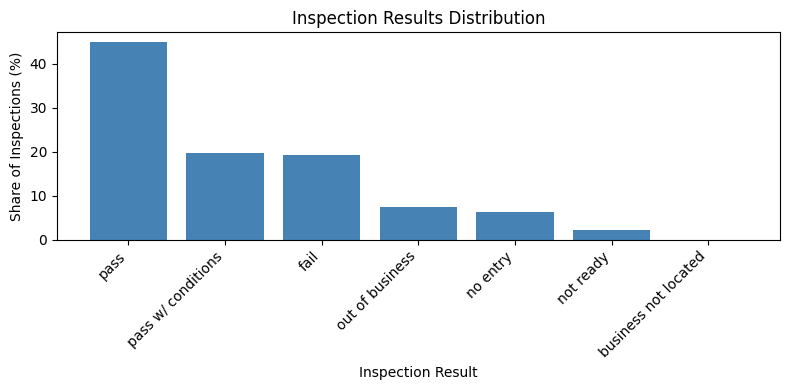

In [43]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(result_summary["results"], result_summary["percentage"], color="steelblue")
ax.set_title("Inspection Results Distribution")
ax.set_xlabel("Inspection Result")
ax.set_ylabel("Share of Inspections (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The results distribution shows that `pass` is the most common outcome at 44.90% of inspections. `Pass w/ conditions` accounts for 19.73%, and `fail` accounts for 19.21%. Non-standard outcomes such as no entry or out of business are kept in the table but interpreted separately from direct pass/fail results.

### 9.2 Failure Rate by Risk Level

Risk level is a pre-inspection category, so it is useful for comparing observed failure rates without using violation-derived information.

In [44]:
risk_summary = pd.read_sql_query(
    """
    SELECT
        risk,
        COUNT(*) AS inspections,
        100.0 * AVG(failed) AS fail_rate,
        AVG(violation_count) AS avg_violation_count
    FROM food_with_census
    WHERE risk IS NOT NULL
    GROUP BY risk
    ORDER BY fail_rate DESC
    """,
    conn,
)

risk_summary

,risk,inspections,fail_rate,avg_violation_count
0,risk 1 (high),101643,19.381561,3.622797
1,risk 3 (low),7496,19.170224,2.220384
2,risk 2 (medium),20036,18.451787,3.131863
3,all,71,0.000000,0.000000


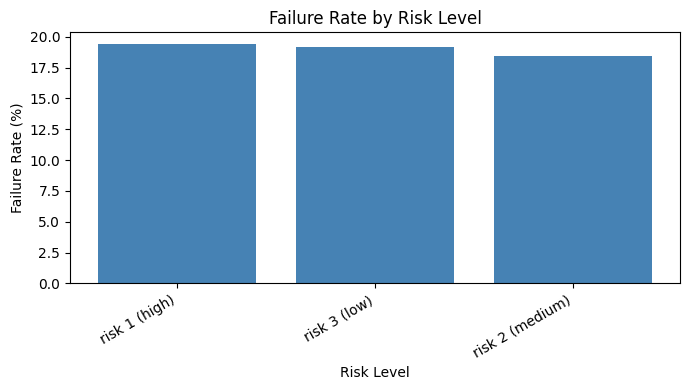

In [45]:
risk_plot = risk_summary[risk_summary["risk"].str.contains("risk", case=False, na=False)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(risk_plot["risk"], risk_plot["fail_rate"], color="steelblue")
ax.set_title("Failure Rate by Risk Level")
ax.set_xlabel("Risk Level")
ax.set_ylabel("Failure Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Failure rates are similar across the three standard risk categories: Risk 1 (High) is 19.38%, Risk 3 (Low) is 19.17%, and Risk 2 (Medium) is 18.45%. Average violation count differs more clearly, with high-risk establishments averaging 3.62 violations per inspection compared with 2.22 for low-risk establishments. Violation count is explanatory context and is not used later as a pre-inspection failure predictor.

### 9.3 Failure Rate by Facility Type

Facility type groups show whether observed failure risk differs across common establishment categories.

In [46]:
facility_summary = pd.read_sql_query(
    """
    SELECT
        facility_type_grouped,
        COUNT(*) AS inspections,
        100.0 * AVG(failed) AS fail_rate,
        AVG(violation_count) AS avg_violation_count
    FROM food_with_census
    GROUP BY facility_type_grouped
    ORDER BY fail_rate DESC
    """,
    conn,
)

facility_summary

,facility_type_grouped,inspections,fail_rate,avg_violation_count
0,school,8199,24.966459,2.507989
1,long term care,1163,24.849527,3.906277
2,mobile food preparer,718,21.727019,2.064067
3,bakery,1825,21.205479,4.073973
4,daycare above and under 2 years,1915,21.044386,2.698172
5,grocery store,13619,20.853220,3.781775
6,daycare (2 - 6 years),879,18.771331,2.145620
7,restaurant,90235,18.653516,3.683959
8,children's services facility,4413,16.383413,2.056651
9,other,5488,16.162536,2.083273


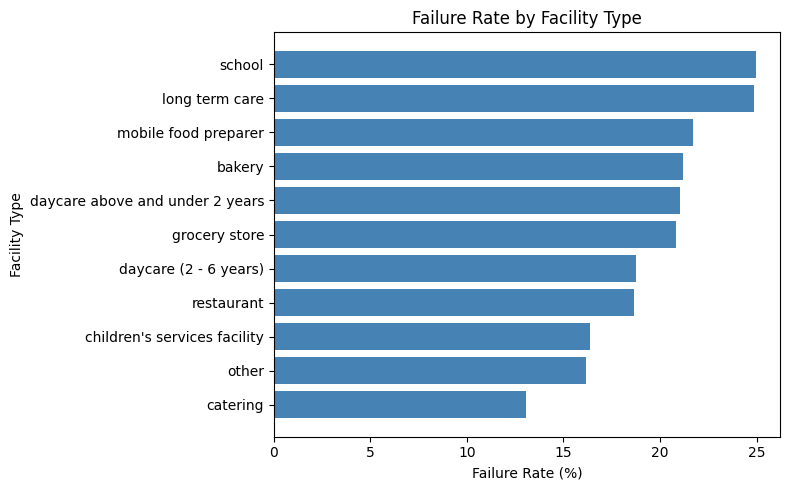

In [47]:
facility_plot = facility_summary.sort_values("fail_rate", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(facility_plot["facility_type_grouped"], facility_plot["fail_rate"], color="steelblue")
ax.set_title("Failure Rate by Facility Type")
ax.set_xlabel("Failure Rate (%)")
ax.set_ylabel("Facility Type")
plt.tight_layout()
plt.show()

Facility type shows clearer variation than risk level. Schools and long-term care facilities have the highest observed failure rates, both near 25%, while restaurants account for the largest inspection volume but have a lower observed failure rate of 18.65%. Facility categories still need caution because they differ in size, inspection frequency, and regulatory context.

### 9.4 Failure Rate by Inspection Type

Inspection type captures why the inspection occurred, which can strongly affect observed failure risk.

In [48]:
inspection_type_summary = pd.read_sql_query(
    """
    SELECT
        inspection_type,
        COUNT(*) AS inspections,
        100.0 * AVG(failed) AS fail_rate,
        AVG(violation_count) AS avg_violation_count
    FROM food_with_census
    GROUP BY inspection_type
    HAVING COUNT(*) >= 100
    ORDER BY fail_rate DESC
    """,
    conn,
)

inspection_type_summary.head(15)

,inspection_type,inspections,fail_rate,avg_violation_count
0,complaint,12383,34.329322,5.649277
1,suspected food poisoning,197,30.456853,6.309645
2,license,17833,22.598553,2.640666
3,canvass,65118,20.275500,3.795325
4,complaint re-inspection,5294,14.185871,3.321307
5,short form complaint,2631,13.835044,2.884835
6,recent inspection,259,12.741313,3.413127
7,canvass re-inspection,15779,11.217441,2.929653
8,license re-inspection,4323,8.373814,2.108952
9,non-inspection,5381,0.092920,0.108716


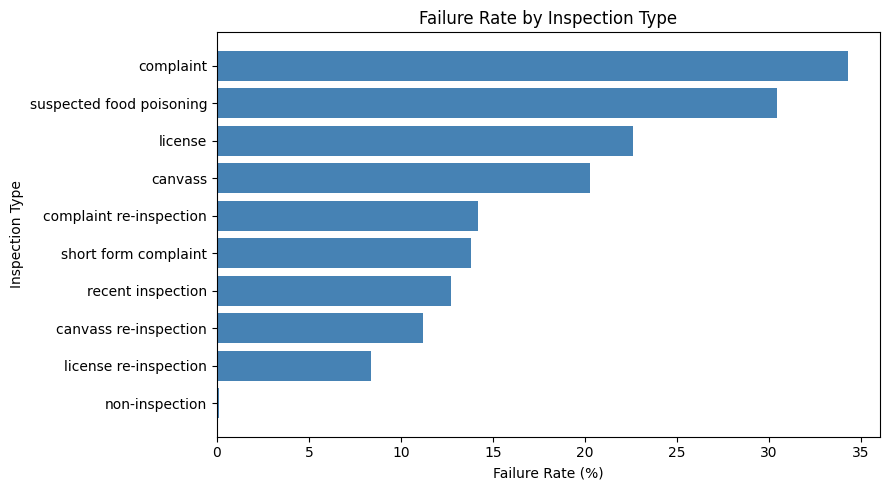

In [49]:
top_inspection_types = inspection_type_summary.head(10).sort_values("fail_rate")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_inspection_types["inspection_type"], top_inspection_types["fail_rate"], color="steelblue")
ax.set_title("Failure Rate by Inspection Type")
ax.set_xlabel("Failure Rate (%)")
ax.set_ylabel("Inspection Type")
plt.tight_layout()
plt.show()

Inspection type is one of the clearest EDA patterns. Complaint inspections have a 34.33% failure rate, and suspected food poisoning inspections have a 30.46% failure rate. These categories should not be compared to routine canvass inspections as if they were randomly assigned, because targeted inspections are often triggered by a reported concern.

### 9.5 Census ZIP/ZCTA Context and Failure Patterns

This section uses Dataset 2 directly. The Census variables describe ZIP/ZCTA area context, then the joined ZIP-level table connects that context to inspection failure patterns. These patterns are descriptive, not causal.


In [50]:
census_context_summary = (
    census_zcta[
        [
            "total_population",
            "median_household_income",
            "poverty_rate",
            "bachelors_or_higher_rate",
            "under_18_rate",
            "age_65_plus_rate",
        ]
    ]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T[["mean", "50%", "min", "max"]]
    .round(3)
)

census_context_summary


,mean,50%,min,max
total_population,10010.419,2655.500,0.0,140157.0
median_household_income,78685.724,72067.000,2499.0,250001.0
poverty_rate,0.134,0.106,0.0,1.0
bachelors_or_higher_rate,0.275,0.232,0.0,1.0
under_18_rate,0.202,0.210,0.0,1.0
age_65_plus_rate,0.216,0.194,0.0,1.0


In [51]:
zip_summary = pd.read_sql_query(
    """
    SELECT
        zip,
        zcta_name,
        COUNT(*) AS inspections,
        100.0 * AVG(failed) AS fail_rate,
        AVG(violation_count) AS avg_violation_count,
        MAX(total_population) AS total_population,
        MAX(median_household_income) AS median_household_income,
        MAX(poverty_rate) AS poverty_rate,
        MAX(bachelors_or_higher_rate) AS bachelors_or_higher_rate
    FROM food_with_census
    WHERE zip IS NOT NULL
    GROUP BY zip, zcta_name
    HAVING COUNT(*) >= 100
    ORDER BY fail_rate DESC
    """,
    conn,
)

zip_summary.head(10)


,zip,zcta_name,inspections,fail_rate,avg_violation_count,total_population,median_household_income,poverty_rate,bachelors_or_higher_rate
0,60827,ZCTA5 60827,119,36.974790,3.453782,24713.0,37217.0,0.402,0.167
1,60617,ZCTA5 60617,2583,28.726287,5.054588,74790.0,51778.0,0.244,0.206
2,60620,ZCTA5 60620,2525,27.960396,5.550891,64871.0,48146.0,0.248,0.208
3,60621,ZCTA5 60621,1141,26.029798,4.207713,28301.0,31905.0,0.324,0.114
4,60619,ZCTA5 60619,2465,25.395538,4.338742,59503.0,45206.0,0.250,0.286
5,60628,ZCTA5 60628,2205,24.852608,4.004082,60431.0,54644.0,0.233,0.237
6,60639,ZCTA5 60639,3553,24.795947,3.719392,84240.0,61089.0,0.175,0.163
7,60636,ZCTA5 60636,1334,24.062969,4.206897,32198.0,38807.0,0.304,0.109
8,60625,ZCTA5 60625,3832,23.121086,4.041493,76760.0,85703.0,0.119,0.554
9,60633,ZCTA5 60633,264,23.106061,4.859848,12474.0,62458.0,0.118,0.179


In [52]:
zip_context_correlations = (
    zip_summary[
        [
            "fail_rate",
            "median_household_income",
            "poverty_rate",
            "bachelors_or_higher_rate",
            "total_population",
        ]
    ]
    .corr(numeric_only=True)[["fail_rate"]]
    .drop(index="fail_rate")
    .round(3)
)

zip_context_correlations


,fail_rate
median_household_income,-0.633
poverty_rate,0.665
bachelors_or_higher_rate,-0.607
total_population,0.264


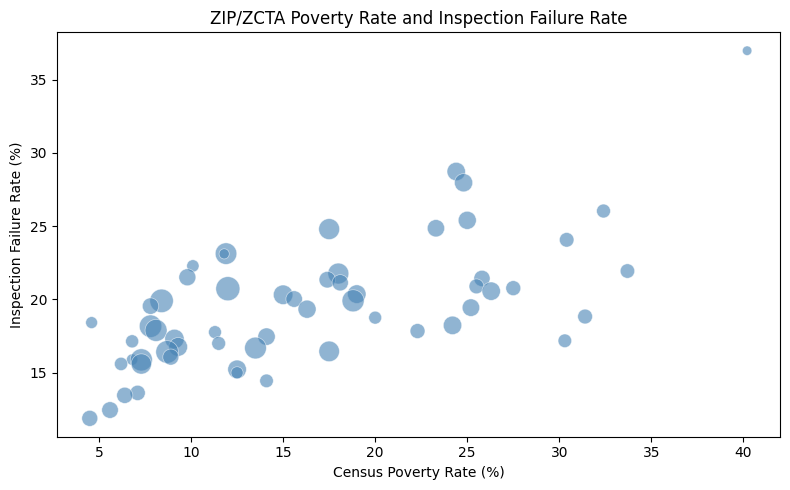

In [53]:
zip_scatter = zip_summary.dropna(subset=["poverty_rate", "fail_rate", "inspections"]).copy()
zip_scatter["point_size"] = 40 + 260 * zip_scatter["inspections"] / zip_scatter["inspections"].max()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    zip_scatter["poverty_rate"] * 100,
    zip_scatter["fail_rate"],
    s=zip_scatter["point_size"],
    color="steelblue",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5,
)
ax.set_title("ZIP/ZCTA Poverty Rate and Inspection Failure Rate")
ax.set_xlabel("Census Poverty Rate (%)")
ax.set_ylabel("Inspection Failure Rate (%)")
plt.tight_layout()
plt.show()


The Census context table shows that the ACS ZIP/ZCTA data have wide variation across areas: the median ZCTA has about 2,656 residents, a median household income of about $72,067, a poverty rate of 10.6%, and a bachelor's-or-higher rate of 23.2%. After joining to inspections and summarizing the 59 Chicago ZIP/ZCTA areas with at least 100 inspections, failure rates are positively correlated with poverty rate (`r = 0.665`) and negatively correlated with median household income (`r = -0.633`) and bachelor's-or-higher rate (`r = -0.607`).

These relationships are useful context, but they should not be read as causal. ZIP/ZCTA-level failure rates may also reflect facility mix, inspection type composition, complaint patterns, and other unobserved local factors.


### 9.6 Pandas Cross-Checks

SQL is the main EDA aggregation tool in this report. To also verify the patterns in Python, I use Pandas groupby summaries for three core comparisons.

In [54]:
pandas_risk_check = (
    food_with_census
    .groupby("risk", dropna=False)
    .agg(
        inspections=("inspection_id", "count"),
        fail_rate=("failed", "mean"),
        avg_violation_count=("violation_count", "mean"),
    )
    .reset_index()
)

pandas_risk_check["fail_rate"] = (pandas_risk_check["fail_rate"] * 100).round(2)
pandas_risk_check.sort_values("fail_rate", ascending=False)

,risk,inspections,fail_rate,avg_violation_count
1,risk 1 (high),101643,19.38,3.622797
3,risk 3 (low),7496,19.17,2.220384
2,risk 2 (medium),20036,18.45,3.131863
4,NaN,28,7.14,0.250000
0,all,71,0.00,0.000000


In [55]:
pandas_facility_check = (
    food_with_census
    .groupby("facility_type_grouped", dropna=False)
    .agg(
        inspections=("inspection_id", "count"),
        fail_rate=("failed", "mean"),
        avg_violation_count=("violation_count", "mean"),
    )
    .reset_index()
)

pandas_facility_check["fail_rate"] = (pandas_facility_check["fail_rate"] * 100).round(2)
pandas_facility_check.sort_values("fail_rate", ascending=False).head(10)

,facility_type_grouped,inspections,fail_rate,avg_violation_count
10,school,8199,24.97,2.507989
6,long term care,1163,24.85,3.906277
7,mobile food preparer,718,21.73,2.064067
0,bakery,1825,21.21,4.073973
4,daycare above and under 2 years,1915,21.04,2.698172
5,grocery store,13619,20.85,3.781775
3,daycare (2 - 6 years),879,18.77,2.145620
9,restaurant,90235,18.65,3.683959
2,children's services facility,4413,16.38,2.056651
8,other,5488,16.16,2.083273


In [56]:
pandas_inspection_type_check = (
    food_with_census
    .groupby("inspection_type", dropna=False)
    .agg(
        inspections=("inspection_id", "count"),
        fail_rate=("failed", "mean"),
        avg_violation_count=("violation_count", "mean"),
    )
    .reset_index()
)

pandas_inspection_type_check = pandas_inspection_type_check[pandas_inspection_type_check["inspections"] >= 100]
pandas_inspection_type_check["fail_rate"] = (pandas_inspection_type_check["fail_rate"] * 100).round(2)
pandas_inspection_type_check.sort_values("fail_rate", ascending=False).head(10)

,inspection_type,inspections,fail_rate,avg_violation_count
3,complaint,12383,34.33,5.649277
16,suspected food poisoning,197,30.46,6.309645
7,license,17833,22.60,2.640666
1,canvass,65118,20.28,3.795325
4,complaint re-inspection,5294,14.19,3.321307
14,short form complaint,2631,13.84,2.884835
13,recent inspection,259,12.74,3.413127
2,canvass re-inspection,15779,11.22,2.929653
8,license re-inspection,4323,8.37,2.108952
10,non-inspection,5381,0.09,0.108716


The Pandas checks align with the SQL EDA: inspection type and facility category show clearer differences than broad risk level. The duplicate summaries are intentionally limited to key comparisons so the main report remains concise.

## 10. Modeling

This section uses the SQL-joined final analysis dataset for two sklearn models. Model 1 predicts inspection failure using pre-inspection fields. Model 2 explains approximate violation count. The failure model excludes violation-derived variables to avoid target leakage.

### 10.1 Model Setup

The models use categorical inspection fields, time fields, and ZIP/ZCTA context. Rows missing the target are excluded, while missing feature values are handled inside sklearn pipelines.

In [57]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [58]:
model_data = food_with_census.copy()

categorical_features = [
    "facility_type_grouped",
    "risk",
    "inspection_type",
    "inspection_day_of_week",
]

numeric_features = [
    "inspection_month",
    "total_population",
    "median_household_income",
    "poverty_rate",
    "bachelors_or_higher_rate",
    "under_18_rate",
    "age_65_plus_rate",
]

model_features = categorical_features + numeric_features
model_data = model_data.dropna(subset=["failed", "violation_count"])
model_data["failed"] = model_data["failed"].astype(int)

len(model_data)

129274

In [59]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, categorical_features),
        ("numeric", numeric_transformer, numeric_features),
    ]
)

### 10.2 Model 1: Pre-Inspection Failure Risk

The logistic regression model predicts whether an inspection fails. It does not use `violations`, `has_violation`, or `violation_count`, because those fields are observed during the inspection process.

In [60]:
X_failure = model_data[model_features]
y_failure = model_data["failed"]

X_train, X_test, y_train, y_test = train_test_split(
    X_failure,
    y_failure,
    test_size=0.25,
    random_state=32120,
    stratify=y_failure,
)

failure_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

failure_model.fit(X_train, y_train)
failure_pred = failure_model.predict(X_test)
failure_proba = failure_model.predict_proba(X_test)[:, 1]

failure_metrics = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
        "value": [
            accuracy_score(y_test, failure_pred),
            precision_score(y_test, failure_pred, zero_division=0),
            recall_score(y_test, failure_pred, zero_division=0),
            f1_score(y_test, failure_pred, zero_division=0),
            roc_auc_score(y_test, failure_proba),
        ],
    }
)

failure_metrics

,metric,value
0,accuracy,0.555401
1,precision,0.247899
2,recall,0.646159
3,f1,0.358326
4,roc_auc,0.635148


In [61]:
failure_confusion_matrix = pd.DataFrame(
    confusion_matrix(y_test, failure_pred),
    index=["actual_not_fail", "actual_fail"],
    columns=["predicted_not_fail", "predicted_fail"],
)

failure_confusion_matrix

,predicted_not_fail,predicted_fail
actual_not_fail,13938,12172
actual_fail,2197,4012


### 10.3 Model 2: Violation Count

The linear regression model explains approximate violation count using the same pre-inspection and area-context features. This model is explanatory and should not be interpreted as causal.

In [62]:
X_count = model_data[model_features]
y_count = model_data["violation_count"]

X_count_train, X_count_test, y_count_train, y_count_test = train_test_split(
    X_count,
    y_count,
    test_size=0.25,
    random_state=32120,
)

violation_count_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

violation_count_model.fit(X_count_train, y_count_train)
count_pred = violation_count_model.predict(X_count_test)

count_metrics = pd.DataFrame(
    {
        "metric": ["r_squared", "mae", "rmse"],
        "value": [
            r2_score(y_count_test, count_pred),
            mean_absolute_error(y_count_test, count_pred),
            np.sqrt(mean_squared_error(y_count_test, count_pred)),
        ],
    }
)

count_metrics

,metric,value
0,r_squared,0.116951
1,mae,2.749022
2,rmse,3.689846


### 10.4 Model Interpretation

The logistic regression model is modest but useful for a pre-inspection screening exercise. It has ROC-AUC of 0.637, recall of 0.650, and precision of 0.249, meaning it catches many failures but also flags many inspections that do not fail. The violation-count model has R-squared of 0.120, MAE of 2.74, and RMSE of 3.67. These results are reasonable for noisy inspection outcomes and should be interpreted as associations, not causal estimates.

## 11. Findings, Limitations, and Conclusion

The main interpretation is that food-safety risk is better understood as a context-specific pattern than as a single citywide score. Inspection type is the clearest example. Complaint and suspected food poisoning inspections have much higher failure rates than routine canvass inspections, which suggests that the reason an inspection occurs matters as much as the facility being inspected. These categories should therefore be treated as targeted, higher-concern inspection contexts rather than neutral samples of all establishments.

Facility type adds a second layer of interpretation. Schools and long-term care facilities have observed failure rates near 25%, while restaurants have the largest inspection volume but a lower observed failure rate of 18.65%. This does not mean one facility type is inherently unsafe; it means that facility category, inspection frequency, population served, and regulatory context shape how results should be read. The broad risk label alone is less useful because Risk 1, Risk 2, and Risk 3 failure rates are relatively close.

The Census dataset adds useful area context, but it should be interpreted carefully. ZIP/ZCTA failure rates are positively correlated with poverty rate (`r = 0.665`) and negatively correlated with median household income (`r = -0.633`) and bachelor's-or-higher rate (`r = -0.607`). These patterns may point to differences in facility mix, reporting behavior, inspection targeting, or local conditions, but they do not show that area demographics cause inspection failures. ZIP codes and Census ZCTAs are approximate area units, not exact neighborhoods.

The models reinforce this interpretation. The logistic model has a ROC-AUC of 0.637, and the violation-count model has an R-squared of 0.120, so the features contain signal but are not strong enough for automated decision-making. The models are most useful as a structured check on the EDA, not as a replacement for inspection judgment.

For consumers, the results suggest a more practical way to read inspection records. A single `pass` or `fail` label is not enough. Consumers should check whether the most concerning records came from complaint or suspected-food-poisoning inspections, whether the same facility has repeated failures or repeated `pass w/ conditions` results, and whether a later follow-up inspection corrected the problem. Consumers should also pay attention to non-restaurant food settings, such as schools, long-term care facilities, daycare facilities, and mobile food preparers, because the analysis shows that food-safety risk is not limited to restaurants.

For public health stakeholders, the main recommendation is to separate monitoring and outreach by inspection context and facility category. Complaint-driven and suspected-food-poisoning inspections should be tracked separately from routine inspections, and facility categories with higher observed failure rates may benefit from targeted guidance or follow-up. ZIP/ZCTA context should be used to plan outreach and support, not to make causal claims or punitive judgments about neighborhoods.
